In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data from previous assignment
try:
    df = pd.read_csv('superstore_cleaned.csv')
    df['Order Date'] = pd.to_datetime(df['Order Date'])
except FileNotFoundError:
    print("Please upload 'superstore_cleaned.csv' to the current directory.")

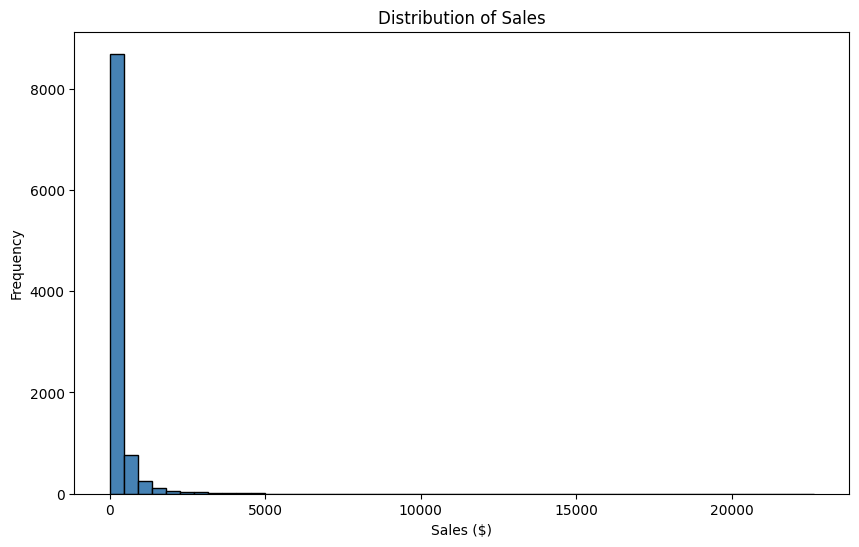

In [18]:
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
    plt.title('Distribution of Sales')
    plt.xlabel('Sales ($)')
    plt.ylabel('Frequency')
    plt.show()

**Interpretation of Sales Histogram**:
The Sales distribution is heavily right-skewed, meaning the vast majority of transactions are for small amounts. There are very few transactions with extremely high sales values extending far to the right.

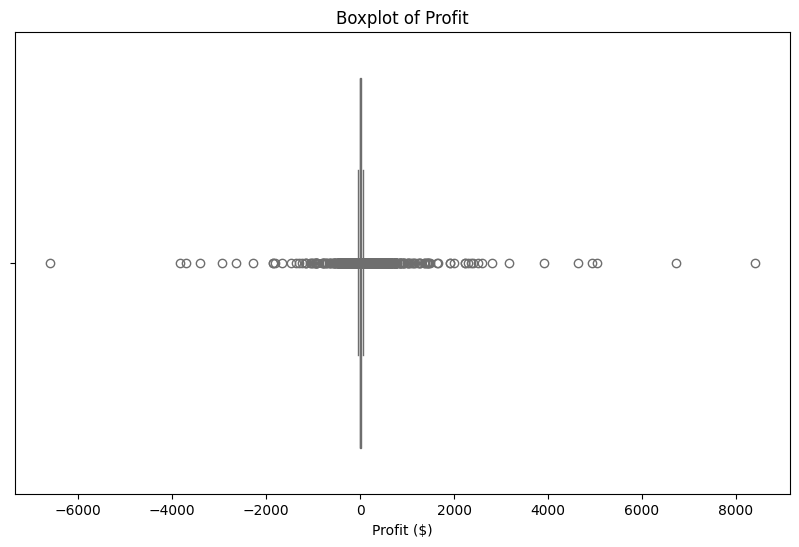

In [19]:
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df['Profit'], color='lightcoral')
    plt.title('Boxplot of Profit')
    plt.xlabel('Profit ($)')
    plt.show()

**Interpretation of Profit Boxplot**:
The quartiles (the box itself) cover a very narrow range around $0, indicating standard profits are mostly low/modest. However, there are massive visible outliers on both the positive (high profit) and negative (high loss) sides.

# Task 2: Category-Wise Trends
Create bar charts showing total sales by Category and by Region.

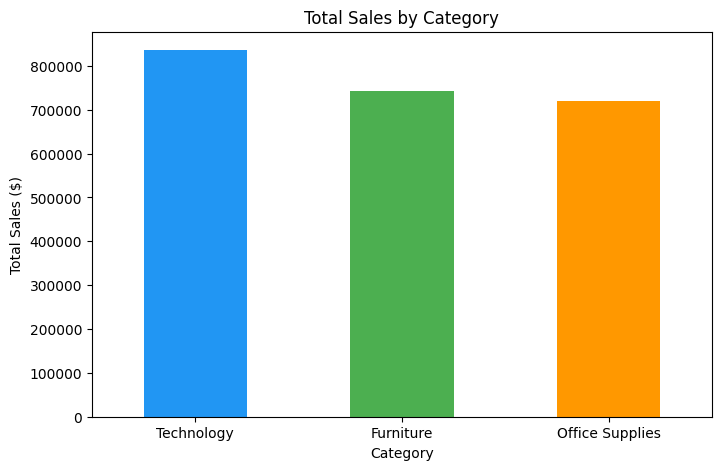

In [20]:
if 'df' in locals():
    cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 5))
    cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
    plt.title('Total Sales by Category')
    plt.xlabel('Category')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=0)
    plt.show()

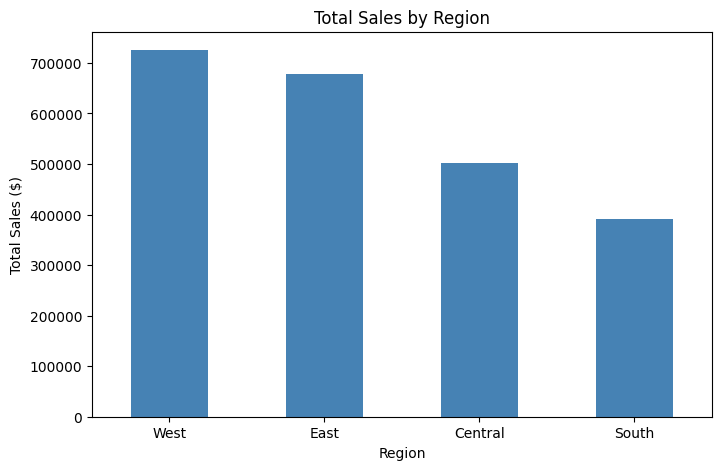

In [21]:
if 'df' in locals():
    region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 5))
    region_sales.plot(kind='bar', color='steelblue')
    plt.title('Total Sales by Region')
    plt.xlabel('Region')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=0)
    plt.show()

**Interpretation of Bar Charts**:
The Technology and Furniture categories generate the most overall revenue. Regionally, the West and East regions lead in sales, while the South generates noticeably less.

# Task 3: Outlier Identification
Numerically identify outliers in the Profit column using the IQR method.

In [22]:
if 'df' in locals():
    Q1 = df['Profit'].quantile(0.25)
    Q3 = df['Profit'].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    
    outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
    print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.2f}%)")

Q1: 1.73, Q3: 29.36, IQR: 27.64
Lower bound: -39.72, Upper bound: 70.82
Number of outliers: 1881 out of 9994 rows (18.82%)


**Interpretation of Outliers**:
The IQR limits capture the majority of standard profit margins. Approximately 19% of the dataset rows represent outliers (profits/losses lying outside the calculated mathematical bounds). They include both high-loss and high-profit transactions.

# Task 4: Correlation Heatmap
Create a correlation heatmap for all numerical columns and identify the strongest relationships.

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


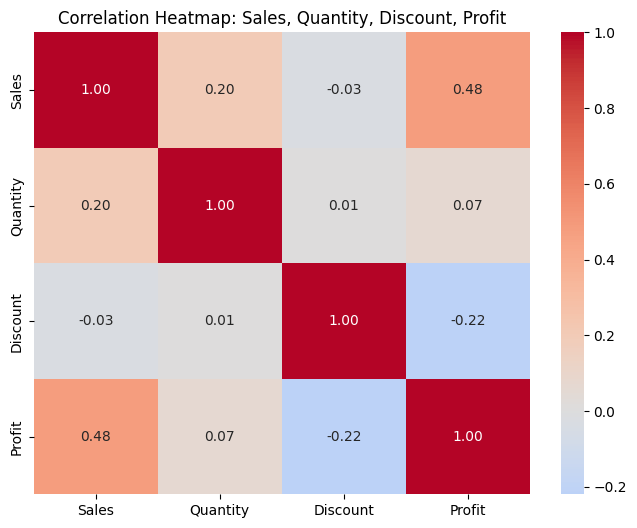

In [23]:
if 'df' in locals():
    numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
    corr_matrix = numerical_cols.corr()
    print(corr_matrix)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
    plt.show()

**Interpretation of Correlation**:
The strongest positive correlation is between Sales and Profit, which is intuitive (higher sales lead to higher profit). There is a distinct negative relationship between Discount and Profit, suggesting that aggressively discounting items usually harms profitability.

# Task 5: Time-Based Trend
Plot monthly total sales over time as a line chart and look for seasonal patterns.

C:\Users\User\AppData\Local\Temp\ipykernel_17600\1302193800.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


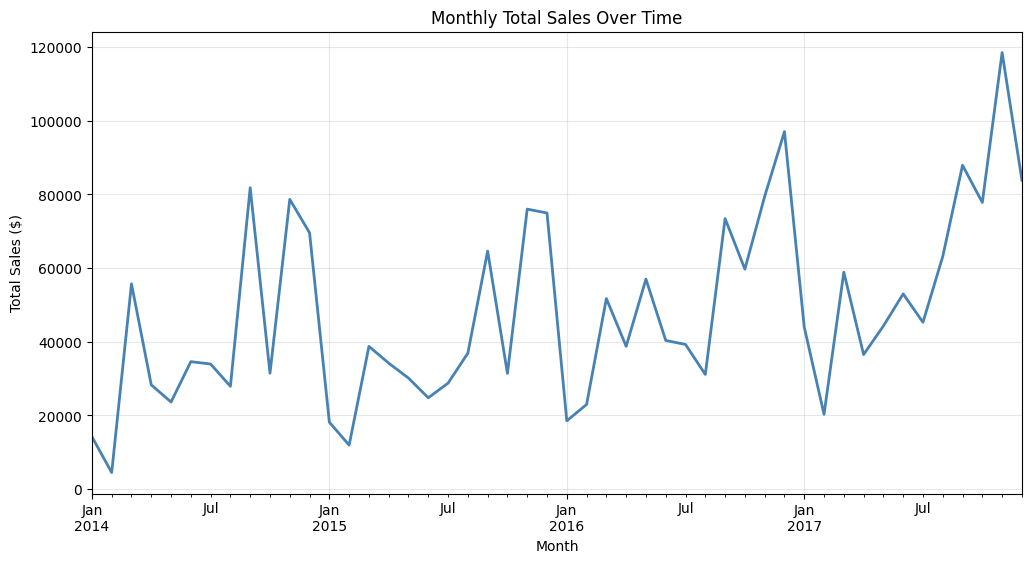

In [24]:
if 'df' in locals():
    monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
    
    plt.figure(figsize=(12, 6))
    monthly_sales.plot(color='steelblue', linewidth=2)
    plt.title('Monthly Total Sales Over Time')
    plt.xlabel('Month')
    plt.ylabel('Total Sales ($)')
    plt.grid(True, alpha=0.3)
    plt.show()

**Interpretation of Time Trends**:
Clear seasonal patterns exist, with massive spikes in sales consistently occurring at the end of each year (likely holiday shopping). Sales usually dip sharply right after the new year in January.

# Task 6: Reflection Questions

1. **The Sales histogram is likely right-skewed. Why does this happen in retail data?**
In retail settings, consumers mostly buy many small, cheap, or everyday items, causing a large spike around low sales figures. At the same time, high-ticket items or bulk enterprise purchases are much rarer, dragging the tail out to the right.

2. **You found outliers in Profit. Should you remove them? What information might you lose?**
Outliers in Profit shouldn't be blindly removed because they often reflect real business dynamics (e.g., clearance blowouts with massive negative profit, or enterprise server sales generating huge positive profit). Eliminating them could misrepresent the true overall profitability of the company and hide the crucial reasons behind huge wins or losses.

3. **If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?**
No, correlation is not causation. While discounts hurt profit margins per transaction, they might be necessary to clear out old inventory, acquire new customers, or increase brand loyalty in the long run. Analyzing strategy is more complex than just avoiding negative margins on a subset of sales.

4. **Looking at your monthly sales trend — if you were a store manager, what action would you take based on this chart?**
Because the spikes occur reliably at year-end, I would ensure that inventory is stocked up early and that seasonal staff is hired well in advance of November to handle the peak shopping period. Conversely, I would minimize labor costs or execute promotions during the slow summer/early-year periods to maintain cash flow.